# The input, from the ground up

**What this notebook is.** The model behind our headline result never sees a light curve. It sees, per flagged event, a flat vector of 37 numbers. This notebook builds that fact up from zero: it opens the frozen dataset, pulls out one real planet event and one real piece of junk, walks every group of the 37 numbers and what question each answers, shows the two image-like views stored for the fall CNN, and ends by feeding both events to the frozen model and reading its answers.

**How to read it.** Every code line carries a comment saying what it does. Each section's markdown says why. The five feature groups here are the same five groups from our discussion: (1) the dip itself, (2) where and around what, (3) does it repeat, (4) the incumbent's own evidence, (5) the circumbinary pair fingerprint.

One framing to hold onto: **the unit of classification is one event, not one light curve.** The search stage already found the dips; our model's only job is, given one dip, planet or junk?

In [1]:
import os, json                      # stdlib: paths and reading small JSON artifacts
import numpy as np                    # all numeric work
import h5py                           # reader for HDF5, the dataset's file format
import matplotlib.pyplot as plt       # plots
import xgboost as xgb                 # the model family that produced the banked result
import sys; sys.path.insert(0, os.path.expanduser('~/cbp-vet'))   # make our package importable
os.chdir(os.path.expanduser('~/cbp-vet'))                          # run from the repo root

from cbpvet.export import schema                     # THE definition of what a record contains
from cbpvet.export.incumbent import INCUMBENT_COLS   # the incumbent vetter's 17 column names

SHARD = 'data/bench/full/bench_full.h5'   # the frozen benchmark: one file, hash-locked
feats = schema.training_scalars(INCUMBENT_COLS)   # the exact 37 features offered to models
print(len(feats), 'features offered to models')    # sanity: must be 37

37 features offered to models


## 1. The dataset is one file with three rooms

The frozen benchmark is a single HDF5 file. HDF5 is just a container that holds named arrays, like a folder of numpy arrays with labels ("hash-locked" means its checksum is on record, so any byte change would be detectable). Ours has three rooms:

- `scalars/`: one named 1-D array per quantity, each of length 188,732 (one entry per event). Row *i* of every array belongs to the same event.
- `local/`: a big array of shape (188,732, 2, 201), the "photo of the dip" per event.
- `recurrence/`: shape (188,732, 2, 64), the "does it repeat" photo per event.

The 37-number vector for event *i* is assembled by reading entry *i* from 37 of the scalar arrays. That is all "the input" physically is. The other stored arrays are audit bookkeeping (labels, split assignments, injection truth) that models are never shown.

In [2]:
f = h5py.File(SHARD, 'r')                      # open the frozen file read-only
n = f['scalars']['label'].shape[0]             # every scalar array has one entry per event
print(f"events               : {n:,}")
print(f"local view per event : {f['local'].shape[1:]}")        # (2 channels, 201 bins)
print(f"recurrence per event : {f['recurrence'].shape[1:]}")   # (2 channels, 64 bins)
print(f"stored scalar arrays : {len(f['scalars'])}")           # more than 37: audit columns live here too

events               : 188,732
local view per event : (2, 201)
recurrence per event : (2, 64)
stored scalar arrays : 63


## 2. The answer key: where the labels come from

Supervised learning needs a label per example. Ours exist because we always know, for every search run, exactly what we planted:

- **label 1**: the flagged dip matches, in time, a transit *we injected* into that light curve. We know the injected epoch exactly, so recovery at that epoch means "this is the planet we planted."
- **label 0**: the flagged dip matches **no** injected epoch. Two flavors exist. A minority (3,672 events) come from running the search on the *pristine* curves, the genuine in-the-wild junk. The majority were flagged *during the injection campaigns*: the search, pointed at an injected (and half the time inverted) curve, also flags dips that are not our injection, and those are junk too, just harvested along the way. `label_source` records the run each event came from, and the banked head-to-head counted its false positives on the pristine-curve 3,672 only, so the headline stands on real junk.

Why keep the campaign junk at all? Volume: a model learns "junk" better from 120 thousand examples than from 3,672, and the leak probes verified the mix does not give the label away.

In [3]:
label = f['scalars']['label'][:]                 # 0/1 answer key, one per event
source = f['scalars']['label_source'][:]         # which RUN flagged it: 0=pristine search, 1=bank campaign, 2=ELC campaign
print(f"positives: {int(label.sum()):,} of {n:,}")
for s, name in [(0, 'pristine-curve search (all junk)'), (1, 'bank-injection campaign'), (2, 'ELC-injection campaign')]:
    m = source == s                              # boolean mask: an array of True/False that picks rows
    print(f"  source {s} {name:31s}: {int(m.sum()):>7,} events, "
          f"{int(label[m].sum()):>6,} positive")

positives: 68,148 of 188,732
  source 0 pristine-curve search (all junk):   3,672 events,      0 positive
  source 1 bank-injection campaign        : 179,277 events, 66,572 positive
  source 2 ELC-injection campaign         :   5,783 events,  1,576 positive


## 3. Two protagonists

For the rest of the notebook we follow two real events:

- **P**, a positive: an injected planet passage that produced the 1-2 punch, a genuinely injected partner crossing nearby. We pick the one whose partner spacing sits closest to 0.2 binary periods, the median of the twelve real observed pairs, so P is as physical as an injected example gets.
- **N**, a negative: junk the real search flagged on a pristine curve.

N is deliberately a hard case. Easy junk needs no machine learning. And P is chosen from the **validation** split, so when we score it later, the model has never trained on it. (The split gloss, once: *train* = the model learns from these; *val* = model selection and demos like this one; *test* = touched exactly once, for the banked table, and never for demos.)

In [4]:
has_pair = f['scalars']['has_observed_pair'][:]              # 1 if a partner dip was observed nearby
truth_dt = f['scalars']['truth_partner_dt'][:]               # AUDIT column: spacing of the partner we truly
                                                             # injected; NaN if none. Fine for choosing a
                                                             # teaching example, never shown to a model.
split = f['scalars']['split'][:].astype(str)                 # frozen split tag per event (bytes -> str)
pair_dt = f['scalars']['pair_dt_over_pbin'][:]               # observed partner spacing, in binary periods

cand = np.where((label == 1) & (has_pair == 1)               # positives with an observed pair...
                & np.isfinite(truth_dt)                      # ...whose partner really was injected...
                & (split == 'val'))[0]                       # ...outside the training set
i_pos = int(cand[np.argmin(np.abs(pair_dt[cand] - 0.2))])    # the one closest to the real-world median spacing
i_neg = int(np.where((label == 0) & (source == 0))[0][0])    # first pristine-curve junk event -> N

def row(i, cols):                                            # helper: read features for ONE event
    return {c: float(f['scalars'][c][i]) for c in cols}      # entry i of each named array

def show(cols):                                              # helper: print P and N side by side
    P, N = row(i_pos, cols), row(i_neg, cols)                # read both events' values
    fmt = lambda x: f"{x:.4g}" if np.isfinite(x) else "NaN"  # NaN printed as NaN, on purpose
    print(f"{'feature':38s}{'P (planet)':>14s}{'N (junk)':>14s}")
    for c in cols:                                           # one aligned line per feature
        print(f"{c:38s}{fmt(P[c]):>14s}{fmt(N[c]):>14s}")

print(f"P is event #{i_pos:,} (split: {split[i_pos]})")      # confirm P sits in val
print(f"N is event #{i_neg:,} (split: {split[i_neg]})")

P is event #102,889 (split: val)
N is event #0 (split: val)


## 4. Group 1: the dip itself

How significant, how deep, how long, how noisy is the neighborhood. These are the numbers a first-guess vetter would use, and they are honest but shallow: junk that survived to a queue is dip-shaped by construction, so this group alone rarely settles anything.

In [5]:
show(['snr', 'depth', 't_dur', 'local_scatter', 'detrend_fraction'])
# snr             : detection significance from the search itself
# depth           : fractional dimming (0.005 = half a percent of the star's light)
# t_dur           : event duration in days
# local_scatter   : noise level of the surrounding out-of-event flux. A printed 1e-06 is the
#                   estimator's FLOOR fallback (used when the sideband estimate fails), not a
#                   real measurement; the validity-bit machinery tells models when that happened.
# detrend_fraction: fraction of the 21 detrending passes (each smooths the curve with a different
#                   window length) that re-found the event; artefacts survive few of them

feature                                   P (planet)      N (junk)
snr                                            28.81          6.37
depth                                        0.00529      0.000584
t_dur                                         0.1042        0.4167
local_scatter                                  1e-06     0.0003395
detrend_fraction                                   1             1


## 5. Group 2: where, and around what

Host-system context, plus *where in the binary's orbit* the dip happened. The phase is stored as sine and cosine rather than a raw 0-to-1 number because phase is circular: 0.99 and 0.01 are neighbors. A raw encoding puts a fake cliff between them; the (sin, cos) pair puts them next to each other, the same trick transformers use for token positions. The tiny demo below makes the cliff visible.

In [6]:
show(['log_p_bin', 'morph_coeff', 'tmag', 'sin_phase', 'cos_phase'])
# log_p_bin  : log10 of the binary's orbital period (the clock everything is phased to)
# morph_coeff: catalogue morphology coefficient of the binary's phased light curve,
#              continuous: near 0 = well-detached pair, toward 1 = contact binary
# tmag       : host brightness (TESS magnitude); sets the photometric noise floor

print()
for ph in (0.99, 0.01):                                     # two phases that LOOK far apart...
    s, c = np.sin(2*np.pi*ph), np.cos(2*np.pi*ph)           # ...encoded on the circle
    print(f"phase {ph:.2f} -> (sin, cos) = ({s:+.3f}, {c:+.3f})")
print('raw distance |0.99-0.01| = 0.98 (a cliff); on the circle they are neighbors')

feature                                   P (planet)      N (junk)
log_p_bin                                      1.111        0.8794
morph_coeff                                  0.08436        0.1729
tmag                                           9.694         10.19
sin_phase                                     -0.963       -0.0799
cos_phase                                    -0.2695        0.9968

phase 0.99 -> (sin, cos) = (-0.063, +0.998)
phase 0.01 -> (sin, cos) = (+0.063, +0.998)
raw distance |0.99-0.01| = 0.98 (a cliff); on the circle they are neighbors


## 6. Group 3: does it repeat? The eclipse killer

The biggest junk class is the binary itself: a badly-masked stellar eclipse. Its tell is that it *recurs every orbit*. So for each event we look near the same orbital phase in all the **other** observed cycles, take each cycle's deepest binned dip there, and summarize. A planet is aperiodic, so its other cycles are quiet; an eclipse dips every time.

One honest subtlety about units: each per-cycle depth is divided by **max(the event's own depth, 3x the local scatter)**, whichever is larger, so the number means "how big is the recurring signal compared to the thing we flagged (or to the noise floor, for very shallow events)". Read each event's value in its own units:

- P below: the other cycles carry only a small fraction of its own dip, quiet, planet-like.
- N below: the recurring signal is *several times larger* than the flagged event itself. In raw terms a roughly 0.7 percent dip repeats at that phase every orbit, about twelve times deeper than the 0.06 percent event that got flagged. That is a stellar eclipse leaking through the mask, caught by one number.

The incumbent pipeline computes nothing like this; its only cross-window check, the Skye metric, clusters event times across *different stars* to catch shared systematics, a different axis entirely.

In [7]:
show(['rec_depth_med', 'rec_depth_mad', 'rec_frac_dipping', 'log1p_n_cycles'])
# rec_depth_med   : median over other cycles of (that cycle's deepest dip near this phase),
#                   divided by max(event depth, 3x local_scatter)  <- the units note above
# rec_depth_mad   : spread of those per-cycle depths (MAD: median absolute deviation, a
#                   robust spread measure that ignores outliers)
# rec_frac_dipping: fraction of other cycles that dip at all at this phase (threshold uses
#                   the same denominator, so the sentinel-scatter caveat from Group 1 applies)
# log1p_n_cycles  : how many other cycles we could check (evidence strength for this group)

feature                                   P (planet)      N (junk)
rec_depth_med                                 0.1001         6.857
rec_depth_mad                                0.03052         0.845
rec_frac_dipping                                   1             1
log1p_n_cycles                                 2.079         2.398


## 7. Group 4: the incumbent's own evidence, uncompressed

mono-cbp's vetting stage fits **four** models to every event: transit, sinusoid, line, step. Its verdict vocabulary has nine classes ("one-hot": nine 0/1 columns, exactly one set to 1): each of the four winners in a *clean* form, each in an *ambiguous* form (the A prefix, meaning the winner fit poorly by a residual test), plus a ninth overall-ambiguous class `A` for no clear winner at all. So `AT` reads **ambiguous transit**: the transit model won, but the fit was poor.

The published funnel acts only on the verdict: events whose class is T or AT go to the human queue. We instead hand the model the **entire evidence table**: the four fit-quality gaps (delta AIC; AIC is a goodness-of-fit score that penalizes extra parameters, and only differences between models matter), the four residual sizes (RMSE), and the one-hot verdict.

Now look at the table below and enjoy the punchline: **P and N carry the exact same verdict, `best_fit_AT = 1`.** The planet and the junk are indistinguishable by verdict alone. That, in one row, is why the verdict-driven funnel needed a human, and why our model gets the evidence instead of the conclusion.

This group is also the control experiment: arm b0 was trained on **only these 17 columns**, and at the incumbent's own stricter operating point it roughly *reproduces* the incumbent, never beats it, which is what a fair harness should show when a model is given no new information.

In [8]:
show(list(INCUMBENT_COLS))
# delta_aic_*: how much worse each model fits than the BEST of the four (the winner sits at 0);
#              huge sinusoid/line/step gaps for both events say: both are strongly dip-shaped
# rmse_*     : absolute residual size of each fit (the A-prefix ambiguity test reads these)
# best_fit_* : the nine-class verdict as one-hot; exactly one of the nine is 1

feature                                   P (planet)      N (junk)
delta_aic_transit                                  0             0
delta_aic_sinusoidal                            1020          1645
delta_aic_linear                                1117          2340
delta_aic_step                                 427.2         819.3
rmse_transit                                   1.909         1.585
rmse_sinusoidal                                4.254         4.063
rmse_linear                                    4.418         4.736
rmse_step                                      3.113         3.078
best_fit_T                                         0             0
best_fit_AT                                        1             1
best_fit_Sin                                       0             0
best_fit_ASin                                      0             0
best_fit_L                                         0             0
best_fit_AL                                        0          

## 8. Group 5: the circumbinary fingerprint, and NaN as information

Within one passage, a circumbinary planet can cross star 1 and then star 2, hours to days apart: the 1-2 punch, the most distinctive thing this planet class does. These features ask: is there a second dip nearby, and does its spacing and shape look physical?

P was chosen to show this block fully lit: partner observed, spacing right at the real-world median, and a depth ratio consistent with the physics-calibrated expectation. N's values are **NaN, not zero**: "no partner exists" is different information from "partner at spacing zero," so undefined stays undefined. XGBoost accepts NaN natively and learns what missingness itself means; filling in a fake number would be a small lie the model could not detect.

In [9]:
show(['has_observed_pair', 'pair_dt_over_pbin', 'pairing_depth_ratio_vs_expectation',
      'pair_duration_ratio', 'log10_pp_over_pbin', 'same_star_multi_allowed'])
# has_observed_pair : is a second dip observed nearby at all
# pair_dt_over_pbin : partner spacing in units of the binary period
#                     (P's 0.200 sits exactly at the median of the twelve real observed pairs)
# pairing_depth_ratio_vs_expectation : partner depth ratio relative to the physics-calibrated
#                     expectation for this host (near the expectation = physical-looking pair)
# pair_duration_ratio: shorter duration / longer duration of the two dips, in (0, 1];
#                     near 1 = equal chords (this pair's crossings happen to run equal),
#                     well below 1 = two different chords, common for two different stars
# log10_pp_over_pbin : log10(innermost stable orbit period / binary period), Holman-Wiegert;
#                     with the project's pinned parameters it evaluates the same for every
#                     event, a design anchor rather than a per-event measurement
# same_star_multi_allowed : whether repeat crossings of ONE star were even possible here

feature                                   P (planet)      N (junk)
has_observed_pair                                  1             0
pair_dt_over_pbin                                0.2           NaN
pairing_depth_ratio_vs_expectation            0.2764           NaN
pair_duration_ratio                                1           NaN
log10_pp_over_pbin                            0.8636        0.5643
same_star_multi_allowed                            0             0


## 9. The two views: what the fall CNN will read

Everything above is a summary someone chose to compute. The dataset also stores the raw material, so a future network can look for patterns no scalar captures:

- **local view (2, 201)**: the dip on a grid normalized to the event's own duration. Channel 0 is flux; channel 1 is a validity mask saying which bins held real data. Gap bins carry a placeholder in the flux channel that would masquerade as clean continuum, which is exactly why the mask channel must always travel with the flux: the mask *declares* the gaps.
- **recurrence view (2, 64)**: the other-cycles stack behind Group 3, as a profile rather than three summary numbers.

The heavy gray striping below is real TESS observing cadence mapped onto the duration-normalized grid, and declaring it honestly is the design point. Note the recurrence panels' scales: P's is small wiggle around zero; N's carries the recurring eclipse signal.

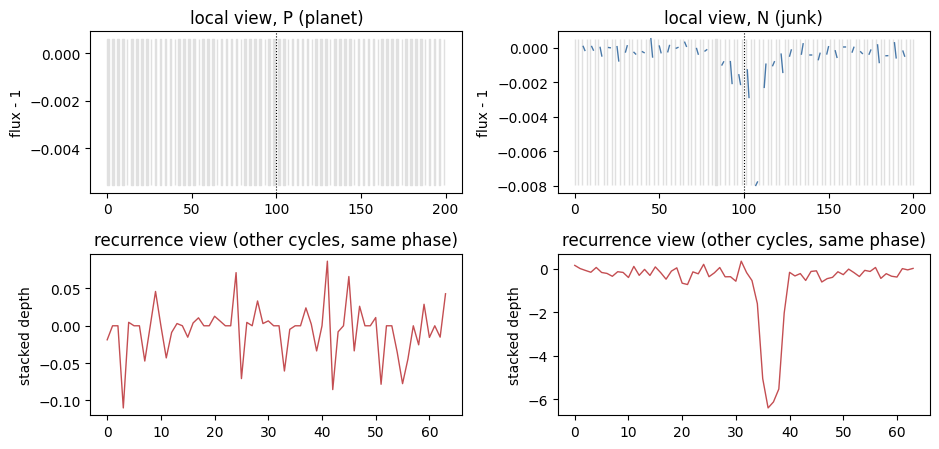

N's recurrence panel is Group 3's number as a picture: the other cycles dip too.


In [10]:
loc = f['local']                                          # (n, 2, 201): [flux, validity] per event
recv = f['recurrence']                                    # (n, 2, 64) : the other-cycles stack
fig, ax = plt.subplots(2, 2, figsize=(9.5, 4.6))          # 2x2 grid: rows = view type, columns = P, N
for col, (i, name) in enumerate([(i_pos, 'P (planet)'), (i_neg, 'N (junk)')]):   # left = P, right = N
    valid = loc[i, 1] > 0.5                               # channel 1: which bins held real data
    flux = np.where(valid, loc[i, 0], np.nan)             # invalid bins drawn as gaps, never as data
    ax[0, col].plot(flux, lw=1, color='#4878a8')          # channel 0: the dip itself
    lo, hi = np.nanmin(flux), np.nanmax(flux)             # y-range from the valid data only
    ax[0, col].fill_between(range(201), lo, hi, where=~valid, color='0.88')   # shade declared gaps
    ax[0, col].axvline(100, color='k', lw=0.8, ls=':')    # mark the event center (bin 100 of 201)
    ax[0, col].set(title=f'local view, {name}', ylabel='flux - 1')
    ax[1, col].plot(recv[i, 0], lw=1, color='#c44e52')    # the stacked other-cycles profile
    ax[1, col].set(title='recurrence view (other cycles, same phase)', ylabel='stacked depth')
plt.tight_layout()                                        # stop panel labels overlapping
plt.show()                                                # render the figure
print('N\'s recurrence panel is Group 3\'s number as a picture: the other cycles dip too.')

## 10. The payoff: vector in, score out

Now the whole mapping runs live. We load the **frozen** model (the exact bytes, hash-logged, that produced the banked result), assemble the 37-number vector for P and for N, and ask for scores. The output is one number per event: the model's confidence this dip is a planet. P sits in the validation split, so its score is earned on an event the model never trained on.

Note what a *good* answer looks like here. P should score high. N is deliberately hard junk that carries a transit-family verdict from the incumbent's own fitter, so the model being *uncertain* about it, rather than confidently wrong, is honest behavior; ranking does the rest.

In [11]:
model = xgb.XGBClassifier()                                    # empty shell of the right family
model.load_model('data/bench/full/models/arm_b_xgb.json')      # load the FROZEN checkpoint bytes

X = np.column_stack([f['scalars'][c][:][[i_pos, i_neg]]        # entry i of each of the 37 arrays,
                     for c in feats])                          # stacked into a (2, 37) matrix
print('input matrix shape:', X.shape, ' <- two events, 37 numbers each')

scores = model.predict_proba(X)[:, 1]                          # column 1 = model's probability of label 1
print(f"P (planet) -> score {scores[0]:.4f}")
print(f"N (junk)   -> score {scores[1]:.4f}   (hard junk: honest uncertainty, not a confident yes)")

input matrix shape: (2, 37)  <- two events, 37 numbers each
P (planet) -> score 0.9963
N (junk)   -> score 0.4858   (hard junk: honest uncertainty, not a confident yes)


## 11. And scoring is ranking

One score means little; the queue is the product. Here we score 2,000 validation events and look at who lives at the top and bottom of the ranking.

One expectation to set before reading the numbers: **this sample is injection-enriched**, roughly a third of it is planted planets, because a benchmark needs positives to learn and measure from. A real deployment queue is almost entirely junk. So the payoff on real sky is not "the top is 99 percent planets"; it is that *junk sinks*, so whatever rare true planet exists surfaces near the top instead of drowning at position nine hundred.

In [12]:
keep = f['scalars']['rebalance_keep'][:] == 1                  # the balance-audited subset models use
idx = np.where((split == 'val') & keep)[0]                     # validation events only, for the demo
rng = np.random.default_rng(0)                                 # fixed seed: the demo reproduces exactly
pick = np.sort(rng.choice(idx, 2000, replace=False))           # 2,000 events, no repeats, sorted for tidy reads

Xv = np.column_stack([f['scalars'][c][:][pick] for c in feats])  # (2000, 37) input matrix
yv = label[pick]                                                 # their true labels, for grading only
sv = model.predict_proba(Xv)[:, 1]                               # 2,000 scores

order = np.argsort(-sv)                                        # indices that sort events best-first
print(f"sample positive rate      : {yv.mean():.1%}   (injection-enriched, see note above)")
print(f"top-200 of the ranking    : {yv[order[:200]].mean():.1%} are true planets")
print(f"bottom-200 of the ranking : {yv[order[-200:]].mean():.1%} are true planets")
print(f"(our protagonists against this queue: P outranks {np.mean(sv < scores[0]):.0%} of it, "
      f"N outranks {np.mean(sv < scores[1]):.0%})")

sample positive rate      : 37.2%   (injection-enriched, see note above)
top-200 of the ranking    : 99.0% are true planets
bottom-200 of the ranking : 2.0% are true planets
(our protagonists against this queue: P outranks 92% of it, N outranks 49%)


The top of the queue is crowded with near-certain planets, so even strong scores land well inside it; easy junk sinks to a bottom that is 2 percent planets; and hard junk like N parks mid-queue, which is exactly the honest place for it, low enough to fall out of a top-slice, never confidently blessed.

## 12. The chain, end to end

light curve → search flags an event → **37 named answers to 37 physical questions** → frozen XGBoost → score → sorted queue.

The arithmetic of the vector, group by group: 5 (the dip) + 5 (context) + 4 (recurrence) + 17 (incumbent evidence) + 6 (pair fingerprint) = **37**.

The two views (section 9) sit in the same file waiting for the fall network, which will test whether raw shapes contain anything the 37 questions miss. Everything printed here came live from the frozen benchmark and the frozen checkpoint; nothing was mocked.